# OIBSIP Data Analytics — Task 2: Customer Segmentation Analysis

**Method:** RFM-style behavioural segmentation with StandardScaler and KMeans.

Features include **Recency, Frequency, Monetary**, plus explicit **Average Purchase Value** and a defined **Lifetime Value proxy (Monetary)**.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path

df=pd.read_csv('../data/customer_transactions.csv',parse_dates=['Purchase_Date'])
print('Shape:',df.shape); print(df.isna().sum()); display(df.head())

Shape: (6000, 6)
Customer_ID         0
Purchase_Date       0
Quantity            0
Unit_Price          0
Total_Amount        0
Product_Category    0
dtype: int64


,Customer_ID,Purchase_Date,Quantity,Unit_Price,Total_Amount,Product_Category
0,C10053,2024-09-05,3,642.16,1926.48,Beverages
1,C10464,2024-09-29,2,703.91,1407.82,Home Care
2,C10392,2024-08-15,4,408.08,1632.32,Grocery
3,C10263,2024-07-14,2,323.75,647.50,Home Care
4,C10259,2024-09-07,3,511.38,1534.14,Home Care


In [2]:
df=df.drop_duplicates().dropna(subset=['Customer_ID','Purchase_Date','Total_Amount'])
ref=df.Purchase_Date.max()+pd.Timedelta(days=1)
rfm=df.groupby('Customer_ID').agg(Recency=('Purchase_Date',lambda x:(ref-x.max()).days),Frequency=('Purchase_Date','count'),Monetary=('Total_Amount','sum')).reset_index()
rfm['Average_Purchase_Value']=rfm.Monetary/rfm.Frequency
rfm['Lifetime_Value_Proxy']=rfm.Monetary
display(rfm.describe())

,Recency,Frequency,Monetary,Average_Purchase_Value,Lifetime_Value_Proxy
count,599.000000,599.000000,599.000000,599.000000,599.000000
mean,14.931553,10.016694,21817.649917,2182.059272,21817.649917
std,14.838946,3.159059,9386.135810,715.898653,9386.135810
min,1.000000,2.000000,1921.530000,615.526000,1921.530000
25%,4.500000,8.000000,14875.620000,1671.864500,14875.620000
50%,10.000000,10.000000,20625.180000,2084.937143,20625.180000
75%,21.000000,12.000000,28032.015000,2541.688333,28032.015000
max,101.000000,19.000000,62219.290000,6863.015000,62219.290000


## Feature selection
RFM features are appropriate because they capture how recently a customer purchased, how often they purchase, and how much they spend. Average Purchase Value adds transaction-value context. The Lifetime Value field is defined here as a **historical monetary-value proxy**, not a forecasted future CLV.

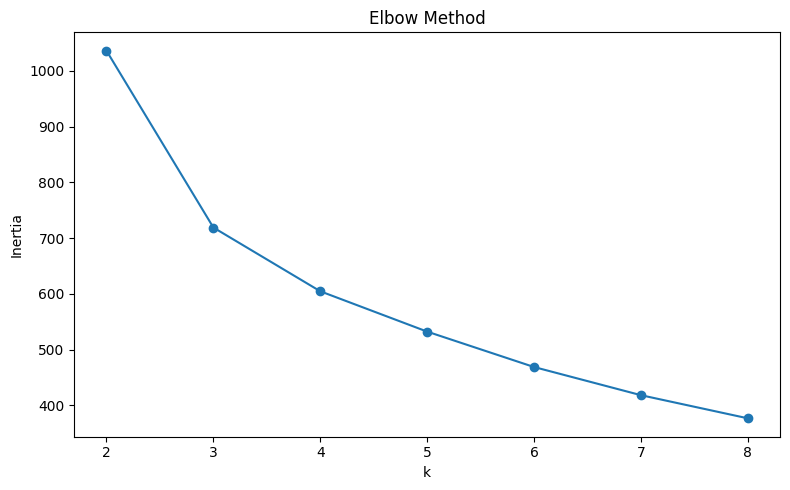

In [3]:
features=['Recency','Frequency','Monetary']
X=StandardScaler().fit_transform(rfm[features])
ks=range(2,9); inertias=[]
for k in ks:
    inertias.append(KMeans(n_clusters=k,random_state=42,n_init=10).fit(X).inertia_)
plt.figure(figsize=(8,5)); plt.plot(list(ks),inertias,marker='o'); plt.title('Elbow Method'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.xticks(list(ks)); plt.tight_layout(); plt.show()

**Observation:** The elbow curve is used to select a practical number of clusters. Four clusters provide a clear, interpretable segmentation for this dataset.

In [4]:
model=KMeans(n_clusters=4,random_state=42,n_init=10)
rfm['Cluster']=model.fit_predict(X)
profile=rfm.groupby('Cluster')[features+['Average_Purchase_Value','Lifetime_Value_Proxy']].mean().round(2)
size=rfm['Cluster'].value_counts().sort_index()
display(profile); display(size.to_frame('Customer_Count'))

,Recency,Frequency,Monetary,Average_Purchase_Value,Lifetime_Value_Proxy
Cluster,,,,,
0,10.45,7.35,14223.86,2016.06,14223.86
1,8.94,13.85,33741.42,2492.13,33741.42
2,44.00,7.15,13670.86,1926.32,13670.86
3,11.39,10.74,23130.06,2206.32,23130.06


,Customer_Count
Cluster,
0,175
1,145
2,81
3,198


In [5]:
# Assign interpretable customer types using rank-based rules
score=profile.copy()
rec_rank=score.Recency.rank(ascending=True); freq_rank=score.Frequency.rank(ascending=False); mon_rank=score.Monetary.rank(ascending=False)
types={}
for c in profile.index:
    if mon_rank[c]<=1.5 and rec_rank[c]<=2: types[c]='Champions / High Value'
    elif rec_rank[c]<=2 and freq_rank[c]<=2: types[c]='Loyal / Frequent'
    elif rec_rank[c]>=3 and mon_rank[c]>=3: types[c]='At-Risk / Low Value'
    else: types[c]='Potential / Growing'
rfm['Customer_Type']=rfm.Cluster.map(types)
marketing={
'Champions / High Value':'VIP rewards, early access and premium cross-sell.',
'Loyal / Frequent':'Loyalty points, bundles and personalized offers.',
'At-Risk / Low Value':'Win-back campaigns, reminders and limited-time incentives.',
'Potential / Growing':'Nurture with bundles, recommendations and frequency incentives.'}
summary=profile.copy(); summary['Customer_Type']=[types[c] for c in summary.index]; summary['Marketing_Action']=[marketing[types[c]] for c in summary.index]; display(summary)

,Recency,Frequency,Monetary,Average_Purchase_Value,Lifetime_Value_Proxy,Customer_Type,Marketing_Action
Cluster,,,,,,,
0,10.45,7.35,14223.86,2016.06,14223.86,Potential / Growing,"Nurture with bundles, recommendations and freq..."
1,8.94,13.85,33741.42,2492.13,33741.42,Champions / High Value,"VIP rewards, early access and premium cross-sell."
2,44.00,7.15,13670.86,1926.32,13670.86,At-Risk / Low Value,"Win-back campaigns, reminders and limited-time..."
3,11.39,10.74,23130.06,2206.32,23130.06,Potential / Growing,"Nurture with bundles, recommendations and freq..."


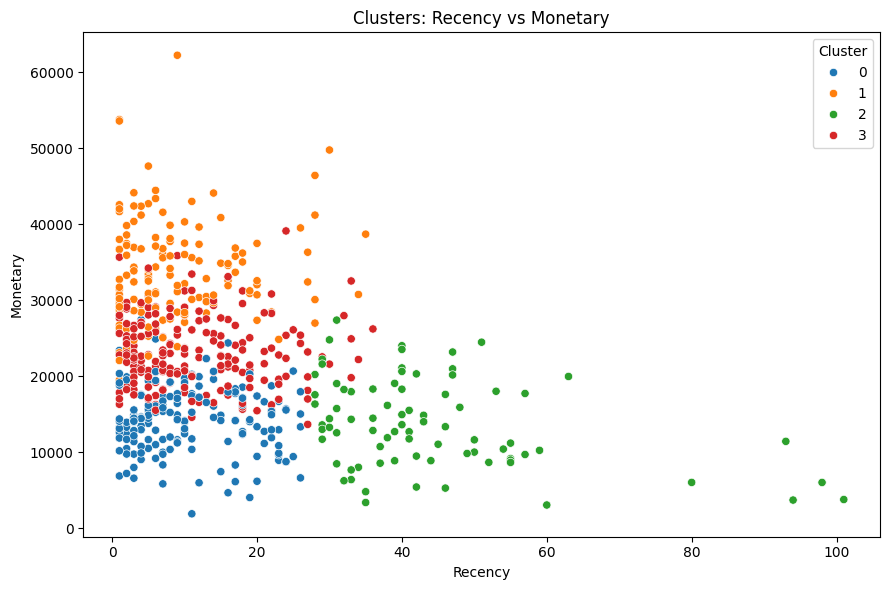

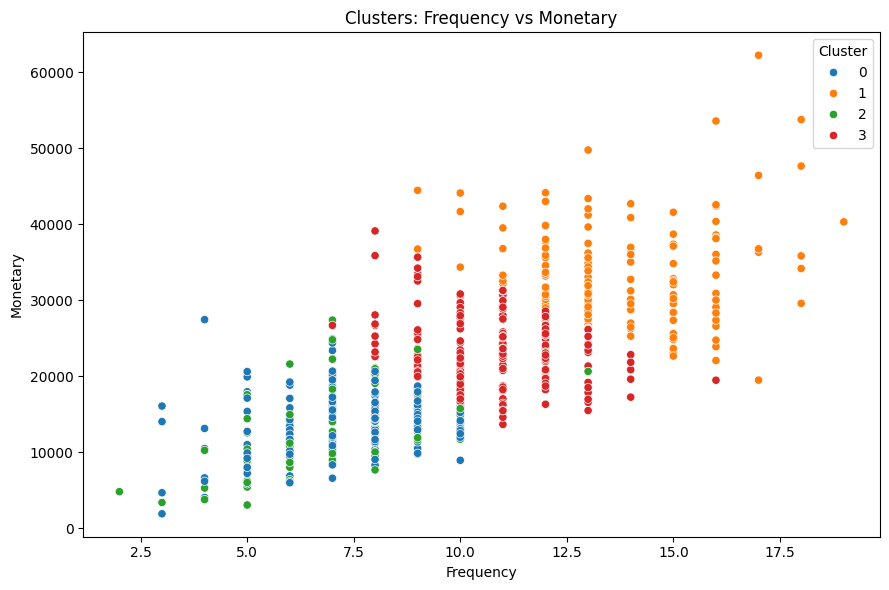

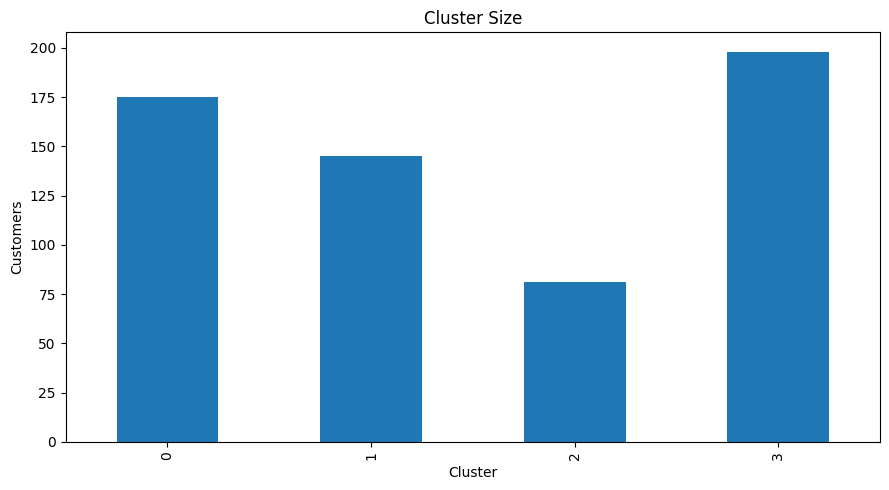

In [6]:
plt.figure(figsize=(9,6)); sns.scatterplot(data=rfm,x='Recency',y='Monetary',hue='Cluster',palette='tab10'); plt.title('Clusters: Recency vs Monetary'); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,6)); sns.scatterplot(data=rfm,x='Frequency',y='Monetary',hue='Cluster',palette='tab10'); plt.title('Clusters: Frequency vs Monetary'); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,5)); size.plot(kind='bar'); plt.title('Cluster Size'); plt.xlabel('Cluster'); plt.ylabel('Customers'); plt.tight_layout(); plt.show()

**Observations:**
- Recency vs Monetary separates recently active high-value customers from lower-value or dormant groups.
- Frequency vs Monetary shows whether spending is driven by repeat behaviour or larger baskets.
- Cluster size reveals whether any segment is small enough for highly personalized campaigns.

In [7]:
rfm.to_csv('../outputs/customer_segments.csv',index=False)
print('Saved:',len(rfm),'customer segment records')

Saved: 599 customer segment records
